## **WEEK 2 - Dataset Cleaning and Preprocessing**

In [27]:
from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import col

spark = SparkSession.builder.appName("4Wheels").getOrCreate()

df = spark.read.csv("/content/drive/MyDrive/Big Data/US_Accidents_March23_sampled_500k.csv", header=True, inferSchema=True)

columns_to_keep = [
    "Severity",
    "Start_Time",
    "City",
    "State",
    "Start_Lat",
    "Start_Lng",
    "Weather_Condition",
    "Temperature(F)",
    "Visibility(mi)",
    "Humidity(%)",
    "Sunrise_Sunset",
    "Junction",
    "Traffic_Signal",
    "Crossing",
    "Stop"
]

df = df.select(columns_to_keep)

print("\nRaw row count:", df.count())
print("Total number of columns:", len(df.columns))
print("Columns:", df.columns)
df.printSchema()

df = (df.withColumn("Temperature(F)", col("Temperature(F)").cast(FloatType()))
        .withColumn("Visibility(mi)", col("Visibility(mi)").cast(FloatType()))
        .withColumn("Humidity(%)", col("Humidity(%)").cast(FloatType())))
print("\nAfter casting to float:")
df.select("Temperature(F)", "Visibility(mi)", "Humidity(%)").printSchema()

before_dropdup = df.count()
df = df.dropDuplicates()
after_dropdup = df.count()
print(f"\nDuplicates removed: {before_dropdup - after_dropdup}")
print(f"Row count after removing duplicates: {after_dropdup}")

before_drop = df.count()
df = df.dropna(subset=["Severity", "Start_Lat", "Start_Lng"])
after_drop = df.count()
print(f"\nRows dropped (missing Severity/Lat/Lng): {before_drop - after_drop}")
print(f"Row count after dropping unrecoverable nulls: {after_drop}")

city_nulls = df.filter(col("City").isNull()).count()
state_nulls = df.filter(col("State").isNull()).count()
print(f"\nCity nulls before fill: {city_nulls}")
print(f"State nulls before fill: {state_nulls}")
df = df.fillna({"City": "Unknown", "State": "Unknown"})

df.write.mode("overwrite").parquet("/content/drive/MyDrive/Big Data/df_4Wheels.parquet")

print("\nFinal row count:", df.count())
df.printSchema()

print("\nSample of cleaned data:")
df.show(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Raw row count: 500000
Total number of columns: 15
Columns: ['Severity', 'Start_Time', 'City', 'State', 'Start_Lat', 'Start_Lng', 'Weather_Condition', 'Temperature(F)', 'Visibility(mi)', 'Humidity(%)', 'Sunrise_Sunset', 'Junction', 'Traffic_Signal', 'Crossing', 'Stop']
root
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Weather_Condition: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Sunrise_Sunset: string (nullable = true)
 |-- Junction: boolean (nullable = true)
 |-- Traffic_Signal: boolean (nullable = true)
 |-- Crossing: boolean (nullable = tr

In [28]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, hour, dayofweek, month, when, percentile_approx, trim, lower

spark = SparkSession.builder.appName("4Wheels").getOrCreate()

df = spark.read.parquet("/content/drive/MyDrive/Big Data/df_4Wheels.parquet")

print("\n--- NULL COUNT PER COLUMN ---")
for c in df.columns:
    null_count = df.filter(col(c).isNull()).count()
    print(c, ":", null_count, "nulls")

df = df.withColumn("Start_Time", to_timestamp(col("Start_Time"), "yyyy-MM-dd HH:mm:ss"))
print("\n\nStart_Time after parsing: ")
df.select("Start_Time").show(5)

df = df.withColumn("Hour", hour(col("Start_Time")))
df = df.withColumn("Day_of_Week", dayofweek(col("Start_Time")))
df = df.withColumn("Month", month(col("Start_Time")))


print("\nNew time columns:")
df.select("Start_Time", "Hour", "Day_of_Week", "Month").show(5)

num_cols = ["Temperature(F)", "Visibility(mi)", "Humidity(%)"]
for c in num_cols:
  median_val = df.select(percentile_approx(c, 0.5)).collect()[0][0]
  df = df.fillna({c: median_val})
  print("Filled", c, "with median:", median_val)

df = df.fillna({"Weather_Condition": "Unknown", "Sunrise_Sunset": "Unknown"})
print("\nWeather_Condition nulls left:", df.filter(col("Weather_Condition").isNull()).count())
print("Sunrise_Sunset nulls left:", df.filter(col("Sunrise_Sunset").isNull()).count())

df = df.withColumn("Weather_Condition",
    when(col("Weather_Condition").contains("rain"), "rain")
    .when(col("Weather_Condition").contains("snow"), "snow")
    .when(col("Weather_Condition").contains("fog"), "fog")
    .when(col("Weather_Condition").contains("cloud"), "cloudy")
    .when(col("Weather_Condition").contains("clear"), "clear")
    .when(col("Weather_Condition").contains("thunder"), "thunderstorm")
    .otherwise(col("Weather_Condition"))
)
print("\nWeather_Condition categories:")
df.groupBy("Weather_Condition").count().orderBy("count", ascending=False).show(10)

print("\n--- FINAL CHECK ---")
print("Total rows:", df.count())
print("Total columns:", len(df.columns))
df.printSchema()
df.show(5)

print("\n--- NULL COUNT PER COLUMN ---")
for c in df.columns:
    null_count = df.filter(col(c).isNull()).count()
    print(c, ":", null_count, "nulls")

df.write.mode("overwrite").parquet("/content/drive/MyDrive/Big Data/Final.parquet")



--- NULL COUNT PER COLUMN ---
Severity : 0 nulls
Start_Time : 0 nulls
City : 0 nulls
State : 0 nulls
Start_Lat : 0 nulls
Start_Lng : 0 nulls
Weather_Condition : 11032 nulls
Temperature(F) : 10407 nulls
Visibility(mi) : 11222 nulls
Humidity(%) : 11067 nulls
Sunrise_Sunset : 1470 nulls
Junction : 0 nulls
Traffic_Signal : 0 nulls
Crossing : 0 nulls
Stop : 0 nulls


Start_Time after parsing: 
+-------------------+
|         Start_Time|
+-------------------+
|2021-11-09 23:47:00|
|2019-10-11 19:58:34|
|2016-08-09 09:48:55|
|2021-02-18 16:14:31|
|2017-01-05 09:11:15|
+-------------------+
only showing top 5 rows

New time columns:
+-------------------+----+-----------+-----+
|         Start_Time|Hour|Day_of_Week|Month|
+-------------------+----+-----------+-----+
|2021-11-09 23:47:00|  23|          3|   11|
|2019-10-11 19:58:34|  19|          6|   10|
|2016-08-09 09:48:55|   9|          3|    8|
|2021-02-18 16:14:31|  16|          5|    2|
|2017-01-05 09:11:15|   9|          5|    1|
+-----

### **EDA (Before)**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")


DATA_PATH = "US_Accidents_March23_sampled_500k.csv"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.autolayout": True})

COLUMNS_TO_KEEP = [
    "Severity", "Start_Time", "City", "State",
    "Start_Lat", "Start_Lng",
    "Weather_Condition", "Temperature(F)", "Visibility(mi)", "Humidity(%)",
    "Sunrise_Sunset",
    "Junction", "Traffic_Signal", "Crossing", "Stop",
]

NUMERIC_COLS     = ["Start_Lat", "Start_Lng", "Temperature(F)",
                    "Visibility(mi)", "Humidity(%)"]
CATEGORICAL_COLS = ["State", "City", "Weather_Condition", "Sunrise_Sunset"]
BOOLEAN_COLS     = ["Junction", "Traffic_Signal", "Crossing", "Stop"]

In [43]:
# 1. LOAD — only selected columns
print("=" * 70)
print("1. LOADING DATA (selected columns only)")
print("=" * 70)

#df = pd.read_csv(DATA_PATH, usecols=COLUMNS_TO_KEEP, low_memory=False)

DATA_PATH = "/content/drive/MyDrive/Big Data/df_4Wheels.parquet"
df = pd.read_parquet(DATA_PATH)

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

1. LOADING DATA (selected columns only)
Shape  : 497,116 rows × 15 columns
Columns: ['Severity', 'Start_Time', 'City', 'State', 'Start_Lat', 'Start_Lng', 'Weather_Condition', 'Temperature(F)', 'Visibility(mi)', 'Humidity(%)', 'Sunrise_Sunset', 'Junction', 'Traffic_Signal', 'Crossing', 'Stop']


In [44]:
# 2. BASIC OVERVIEW
print("\n" + "=" * 70)
print("2. BASIC OVERVIEW")
print("=" * 70)

print("\n── dtypes ──")
print(df.dtypes.to_string())

print("\n── First 5 rows ──")
print(df.head(5).to_string())

print("\n── Memory usage ──")
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Total: {mem_mb:.1f} MB")


2. BASIC OVERVIEW

── dtypes ──
Severity                      int32
Start_Time           datetime64[ns]
City                         object
State                        object
Start_Lat                   float64
Start_Lng                   float64
Weather_Condition            object
Temperature(F)              float32
Visibility(mi)              float32
Humidity(%)                 float32
Sunrise_Sunset               object
Junction                       bool
Traffic_Signal                 bool
Crossing                       bool
Stop                           bool

── First 5 rows ──
   Severity          Start_Time        City State  Start_Lat   Start_Lng Weather_Condition  Temperature(F)  Visibility(mi)  Humidity(%) Sunrise_Sunset  Junction  Traffic_Signal  Crossing   Stop
0         2 2021-02-16 16:37:36      Clover    SC  35.102829  -81.092438              Fair            51.0            10.0         46.0            Day     False            True      True  False
1         2 2018-01


3. MISSING VALUES
                   missing_count  missing_%
Visibility(mi)             11222       2.26
Humidity(%)                11067       2.23
Weather_Condition          11032       2.22
Temperature(F)             10407       2.09
Sunrise_Sunset              1470       0.30


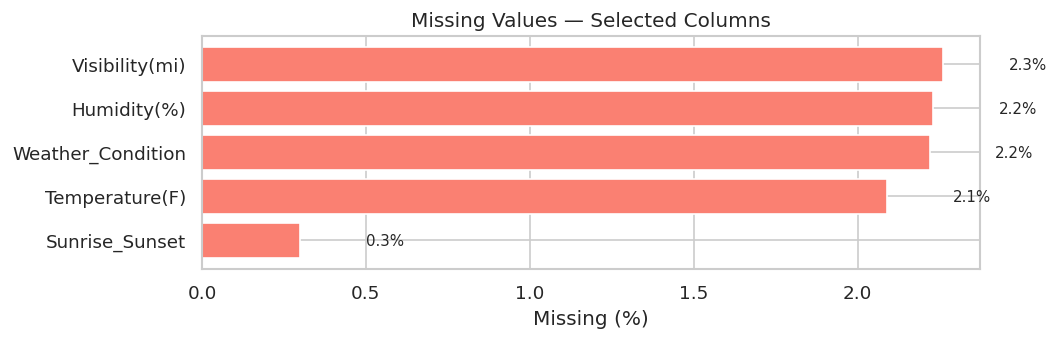

In [45]:
# 3. MISSING VALUES
print("\n" + "=" * 70)
print("3. MISSING VALUES")
print("=" * 70)

missing = (
    df.isnull()
      .sum()
      .rename("missing_count")
      .to_frame()
)
missing["missing_%"] = (missing["missing_count"] / len(df) * 100).round(2)
missing_nonzero = missing[missing["missing_count"] > 0].sort_values("missing_%", ascending=False)

if missing_nonzero.empty:
    print("No missing values found in selected columns.")
else:
    print(missing_nonzero.to_string())
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing_nonzero) * 0.55)))
    ax.barh(missing_nonzero.index, missing_nonzero["missing_%"], color="salmon", edgecolor="white")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values — Selected Columns")
    ax.invert_yaxis()
    for i, (val, label) in enumerate(zip(missing_nonzero["missing_%"], missing_nonzero.index)):
        ax.text(val + 0.2, i, f"{val:.1f}%", va="center", fontsize=9)
    plt.show()

In [46]:
# 4. DUPLICATE ROWS
print("\n" + "=" * 70)
print("4. DUPLICATE ROWS")
print("=" * 70)

n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup:,}")


4. DUPLICATE ROWS
Duplicate rows: 0



5. TARGET VARIABLE — Severity
           count      %
Severity               
1           4253   0.86
2         395367  79.53
3          84469  16.99
4          13027   2.62


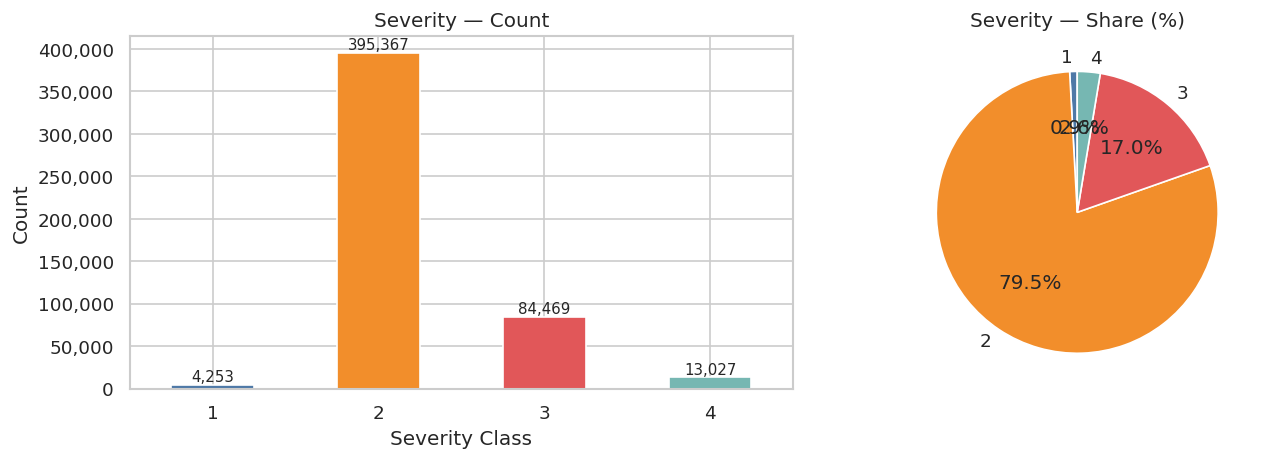

In [47]:
# 5. TARGET VARIABLE — Severity
print("\n" + "=" * 70)
print("5. TARGET VARIABLE — Severity")
print("=" * 70)

sev_counts = df["Severity"].value_counts().sort_index()
sev_pct    = (sev_counts / sev_counts.sum() * 100).round(2)
print(pd.DataFrame({"count": sev_counts, "%": sev_pct}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

sev_counts.plot(kind="bar", ax=axes[0], color=colors[:len(sev_counts)], edgecolor="white")
axes[0].set_title("Severity — Count")
axes[0].set_xlabel("Severity Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500, f"{int(bar.get_height()):,}",
                 ha="center", va="bottom", fontsize=9)

sev_pct.plot(kind="pie", ax=axes[1], autopct="%1.1f%%",
             startangle=90, colors=colors[:len(sev_counts)])
axes[1].set_title("Severity — Share (%)")
axes[1].set_ylabel("")

plt.show()


7. OUTLIER DETECTION (IQR method)
                     Q1      Q3     IQR  lower_fence  upper_fence  outlier_count  outlier_%
column                                                                                     
Start_Lat        33.426  40.084   6.657       23.440       50.070              0       0.00
Start_Lng      -117.236 -80.365  36.871     -172.542      -25.059              0       0.00
Temperature(F)   49.000  76.000  27.000        8.500      116.500           3335       0.69
Visibility(mi)   10.000  10.000   0.000       10.000       10.000          95552      19.67
Humidity(%)      48.000  84.000  36.000       -6.000      138.000              0       0.00


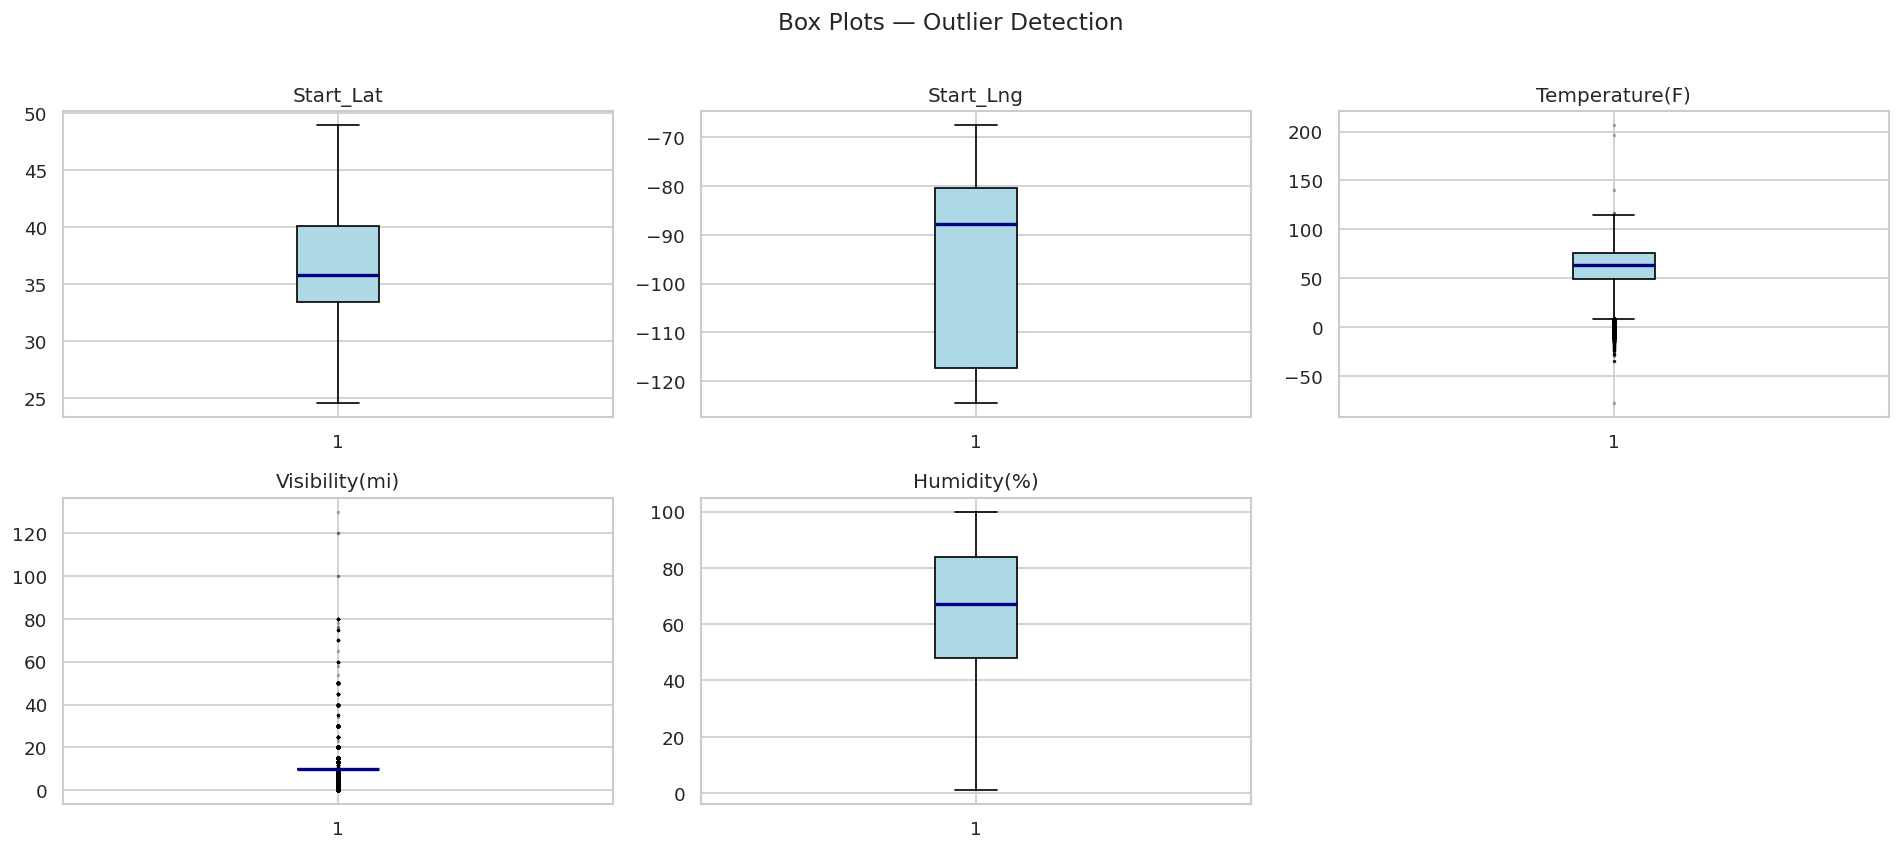

In [49]:
# 7. OUTLIER DETECTION — IQR method
print("\n" + "=" * 70)
print("7. OUTLIER DETECTION (IQR method)")
print("=" * 70)

outlier_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((s < lo) | (s > hi)).sum()
    outlier_rows.append({
        "column": col,
        "Q1": round(Q1, 3), "Q3": round(Q3, 3), "IQR": round(IQR, 3),
        "lower_fence": round(lo, 3), "upper_fence": round(hi, 3),
        "outlier_count": n_out,
        "outlier_%": round(n_out / len(s) * 100, 2),
    })

out_df = pd.DataFrame(outlier_rows).set_index("column")
print(out_df.to_string())

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(
        df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor="lightblue"),
        medianprops=dict(color="navy", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Box Plots — Outlier Detection", fontsize=14, y=1.01)
plt.show()


8. CORRELATION MATRIX
                Severity  Start_Lat  Start_Lng  Temperature(F)  Visibility(mi)  Humidity(%)
Severity           1.000      0.069      0.054          -0.018           0.000        0.019
Start_Lat          0.069      1.000     -0.066          -0.443          -0.086        0.020
Start_Lng          0.054     -0.066      1.000          -0.010          -0.013        0.177
Temperature(F)    -0.018     -0.443     -0.010           1.000           0.213       -0.331
Visibility(mi)     0.000     -0.086     -0.013           0.213           1.000       -0.381
Humidity(%)        0.019      0.020      0.177          -0.331          -0.381        1.000


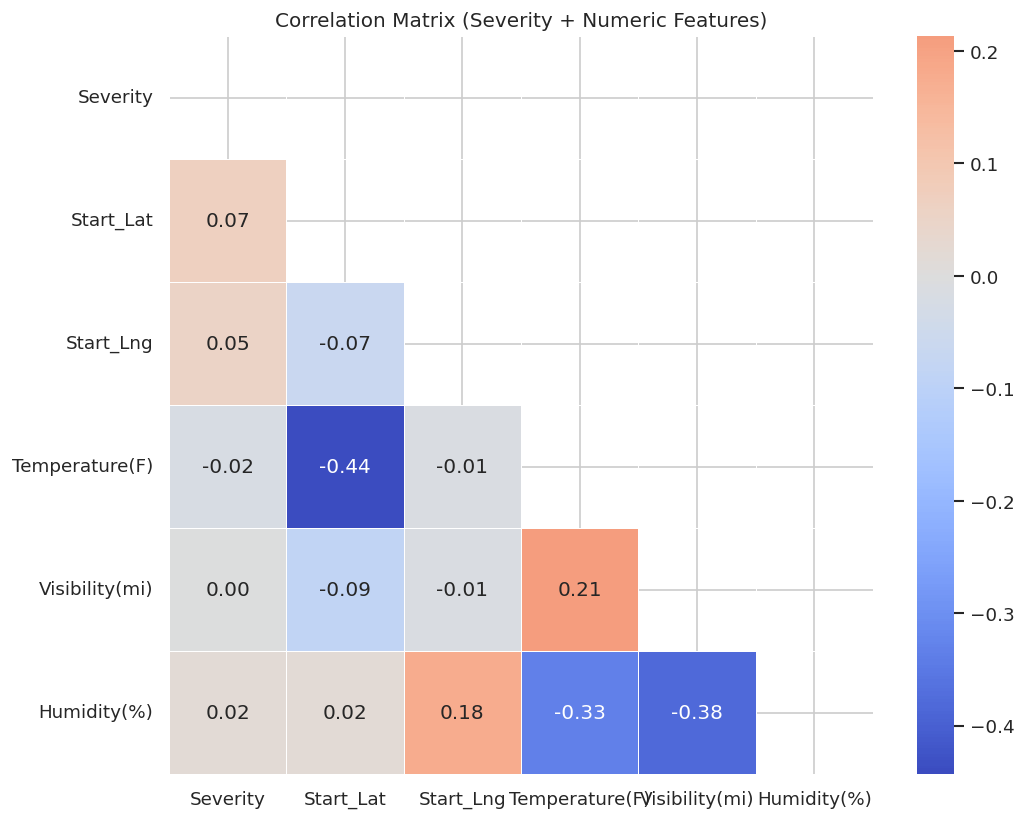

In [50]:
# 8. CORRELATION MATRIX (numeric + severity)
print("\n" + "=" * 70)
print("8. CORRELATION MATRIX")
print("=" * 70)

corr_cols = ["Severity"] + NUMERIC_COLS
corr = df[corr_cols].corr()
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix (Severity + Numeric Features)")
plt.show()


9. CATEGORICAL COLUMNS — Cardinality & top values

State — 49 unique values (missing: 0)
State
CA    112730
FL     55949
TX     37233
SC     24668
NY     22444

City — 9,489 unique values (missing: 0)
City
Miami          11852
Houston        10989
Los Angeles    10251
Charlotte       8904
Dallas          8203

Weather_Condition — 108 unique values (missing: 11,032)
Weather_Condition
Fair             164761
Mostly Cloudy     65032
Cloudy            52701
Clear             52367
Partly Cloudy     44845

Sunrise_Sunset — 2 unique values (missing: 1,470)
Sunrise_Sunset
Day      342953
Night    152693


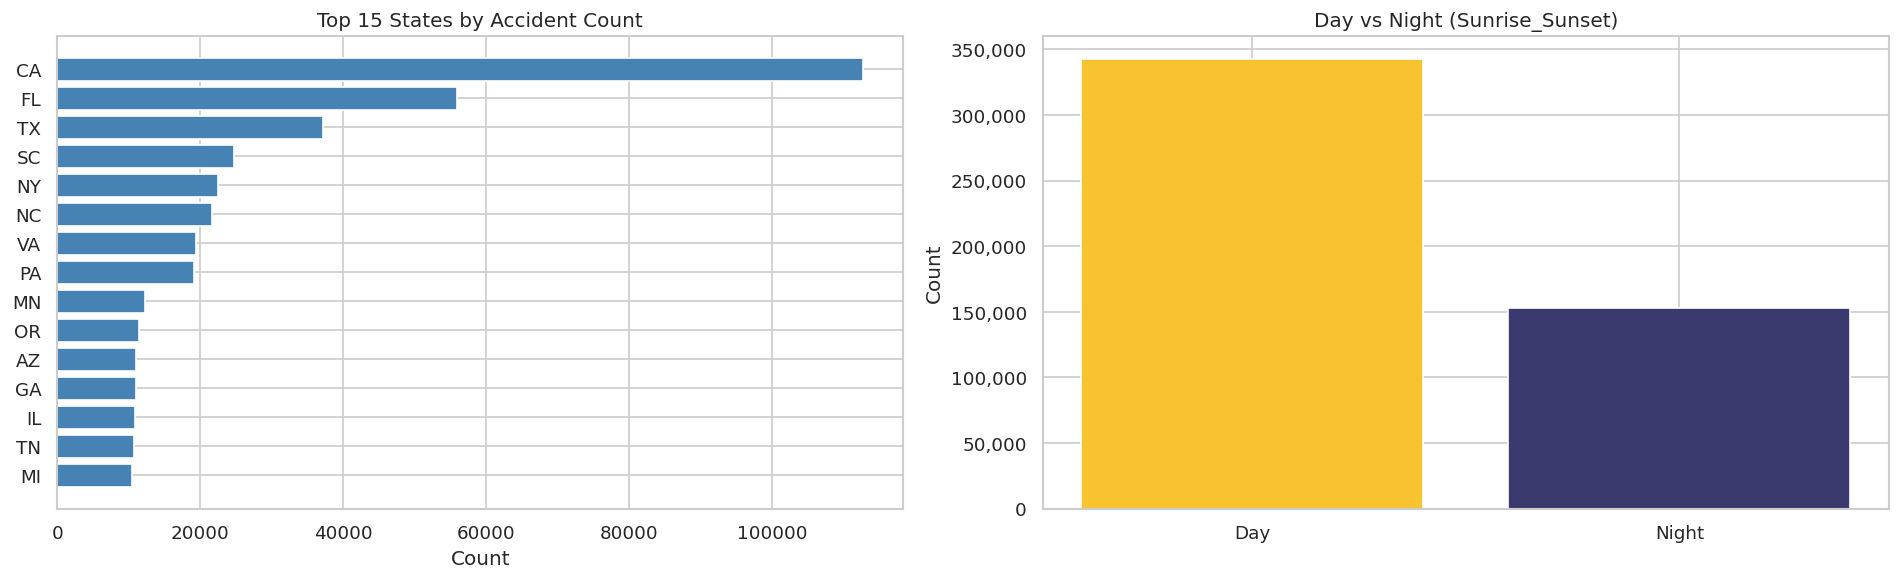

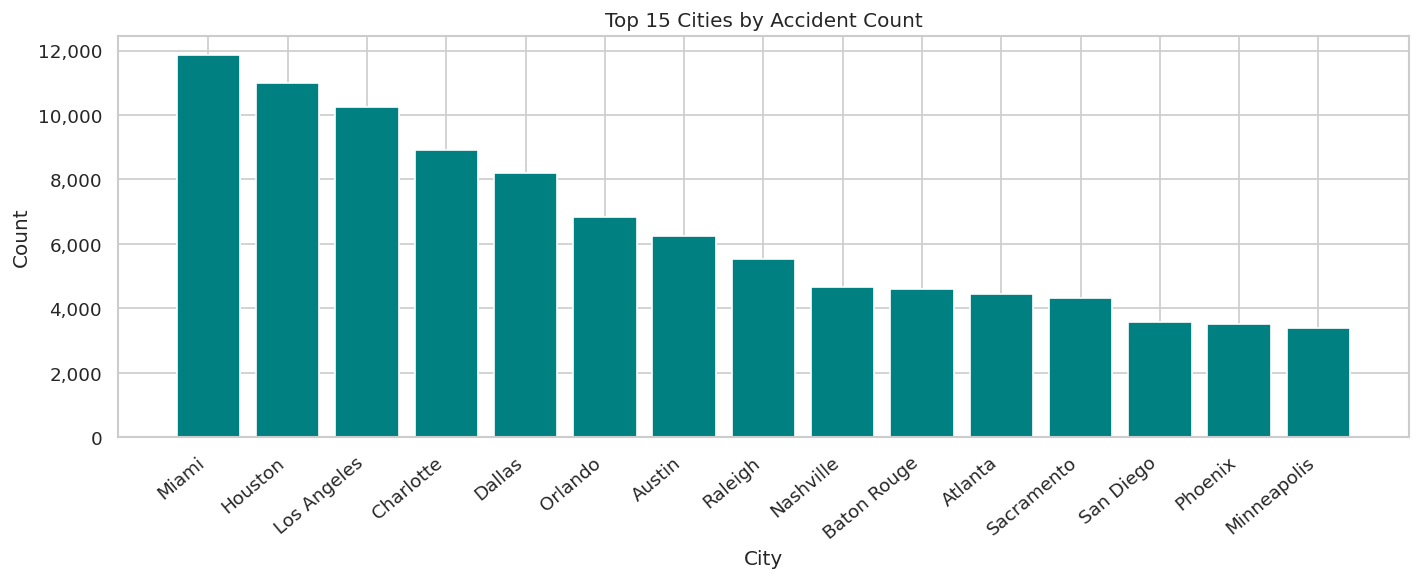

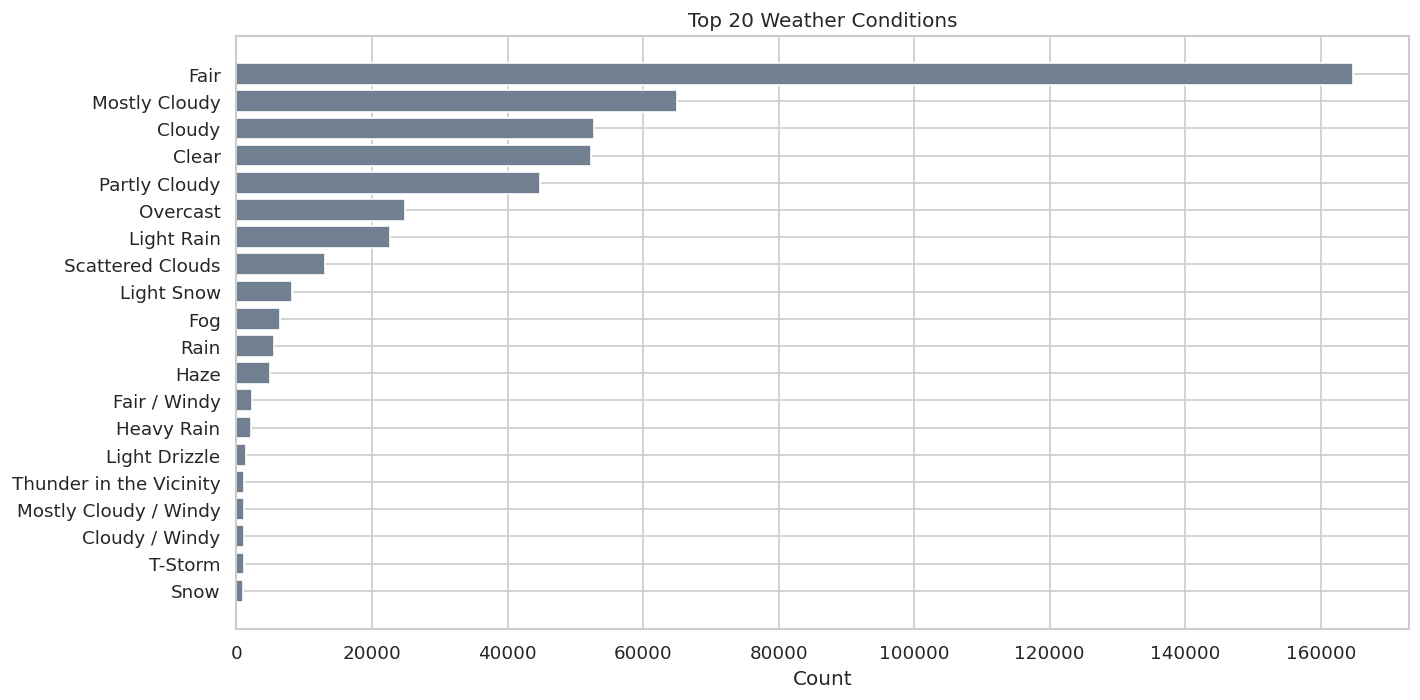

In [51]:
# 9. CATEGORICAL COLUMNS
print("\n" + "=" * 70)
print("9. CATEGORICAL COLUMNS — Cardinality & top values")
print("=" * 70)

for col in CATEGORICAL_COLS:
    n_unique = df[col].nunique()
    top5 = df[col].value_counts().head(5)
    print(f"\n{col} — {n_unique:,} unique values (missing: {df[col].isnull().sum():,})")
    print(top5.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_states = df["State"].value_counts().head(15)
axes[0].barh(top_states.index[::-1], top_states.values[::-1], color="steelblue")
axes[0].set_title("Top 15 States by Accident Count")
axes[0].set_xlabel("Count")

ss = df["Sunrise_Sunset"].value_counts()
axes[1].bar(ss.index, ss.values, color=["#f7c430", "#3a3a6e"], edgecolor="white")
axes[1].set_title("Day vs Night (Sunrise_Sunset)")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
top_cities = df["City"].value_counts().head(15)
ax.bar(top_cities.index, top_cities.values, color="teal", edgecolor="white")
ax.set_title("Top 15 Cities by Accident Count")
ax.set_xlabel("City")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=40, ha="right")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
top_weather = df["Weather_Condition"].value_counts().head(20)
ax.barh(top_weather.index[::-1], top_weather.values[::-1], color="slategray")
ax.set_title("Top 20 Weather Conditions")
ax.set_xlabel("Count")
plt.show()


10. BOOLEAN COLUMNS — True/False counts
                True_count  False_count  True_%
Junction             36871       460245    7.42
Traffic_Signal       73765       423351   14.84
Crossing             55840       441276   11.23
Stop                 13946       483170    2.81


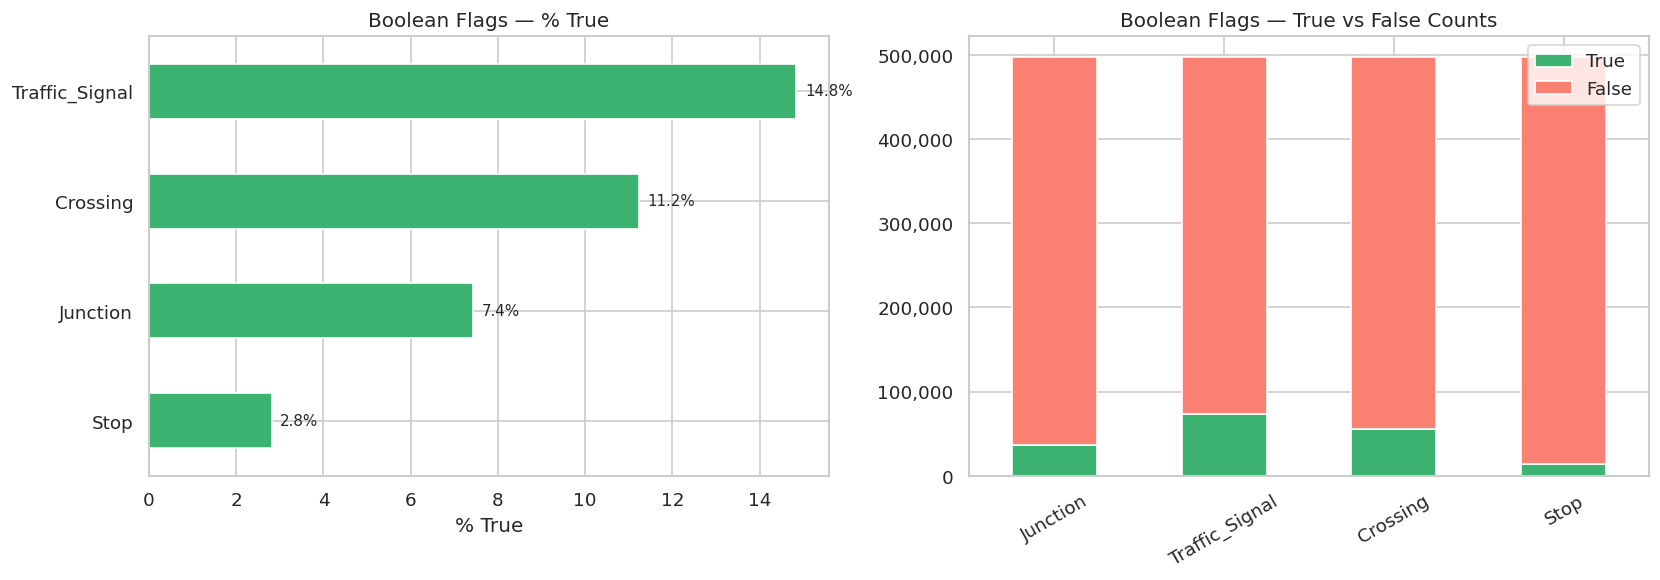

In [52]:
# 10. BOOLEAN / FLAG COLUMNS
print("\n" + "=" * 70)
print("10. BOOLEAN COLUMNS — True/False counts")
print("=" * 70)

bool_summary = pd.DataFrame({
    "True_count":  df[BOOLEAN_COLS].sum(),
    "False_count": (~df[BOOLEAN_COLS]).sum(),
    "True_%":      (df[BOOLEAN_COLS].mean() * 100).round(2),
})
print(bool_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bool_summary["True_%"].sort_values().plot(
    kind="barh", ax=axes[0], color="mediumseagreen", edgecolor="white"
)
axes[0].set_title("Boolean Flags — % True")
axes[0].set_xlabel("% True")
for i, val in enumerate(bool_summary["True_%"].sort_values()):
    axes[0].text(val + 0.2, i, f"{val:.1f}%", va="center", fontsize=9)

bool_summary[["True_count", "False_count"]].plot(
    kind="bar", ax=axes[1], color=["mediumseagreen", "salmon"],
    edgecolor="white", stacked=True
)
axes[1].set_title("Boolean Flags — True vs False Counts")
axes[1].tick_params(axis="x", rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].legend(["True", "False"])

plt.show()


11. DATETIME ANALYSIS — Start_Time
Unparseable timestamps : 0
Date range             : 2016-01-14 20:18:33 → 2023-03-31 22:46:13


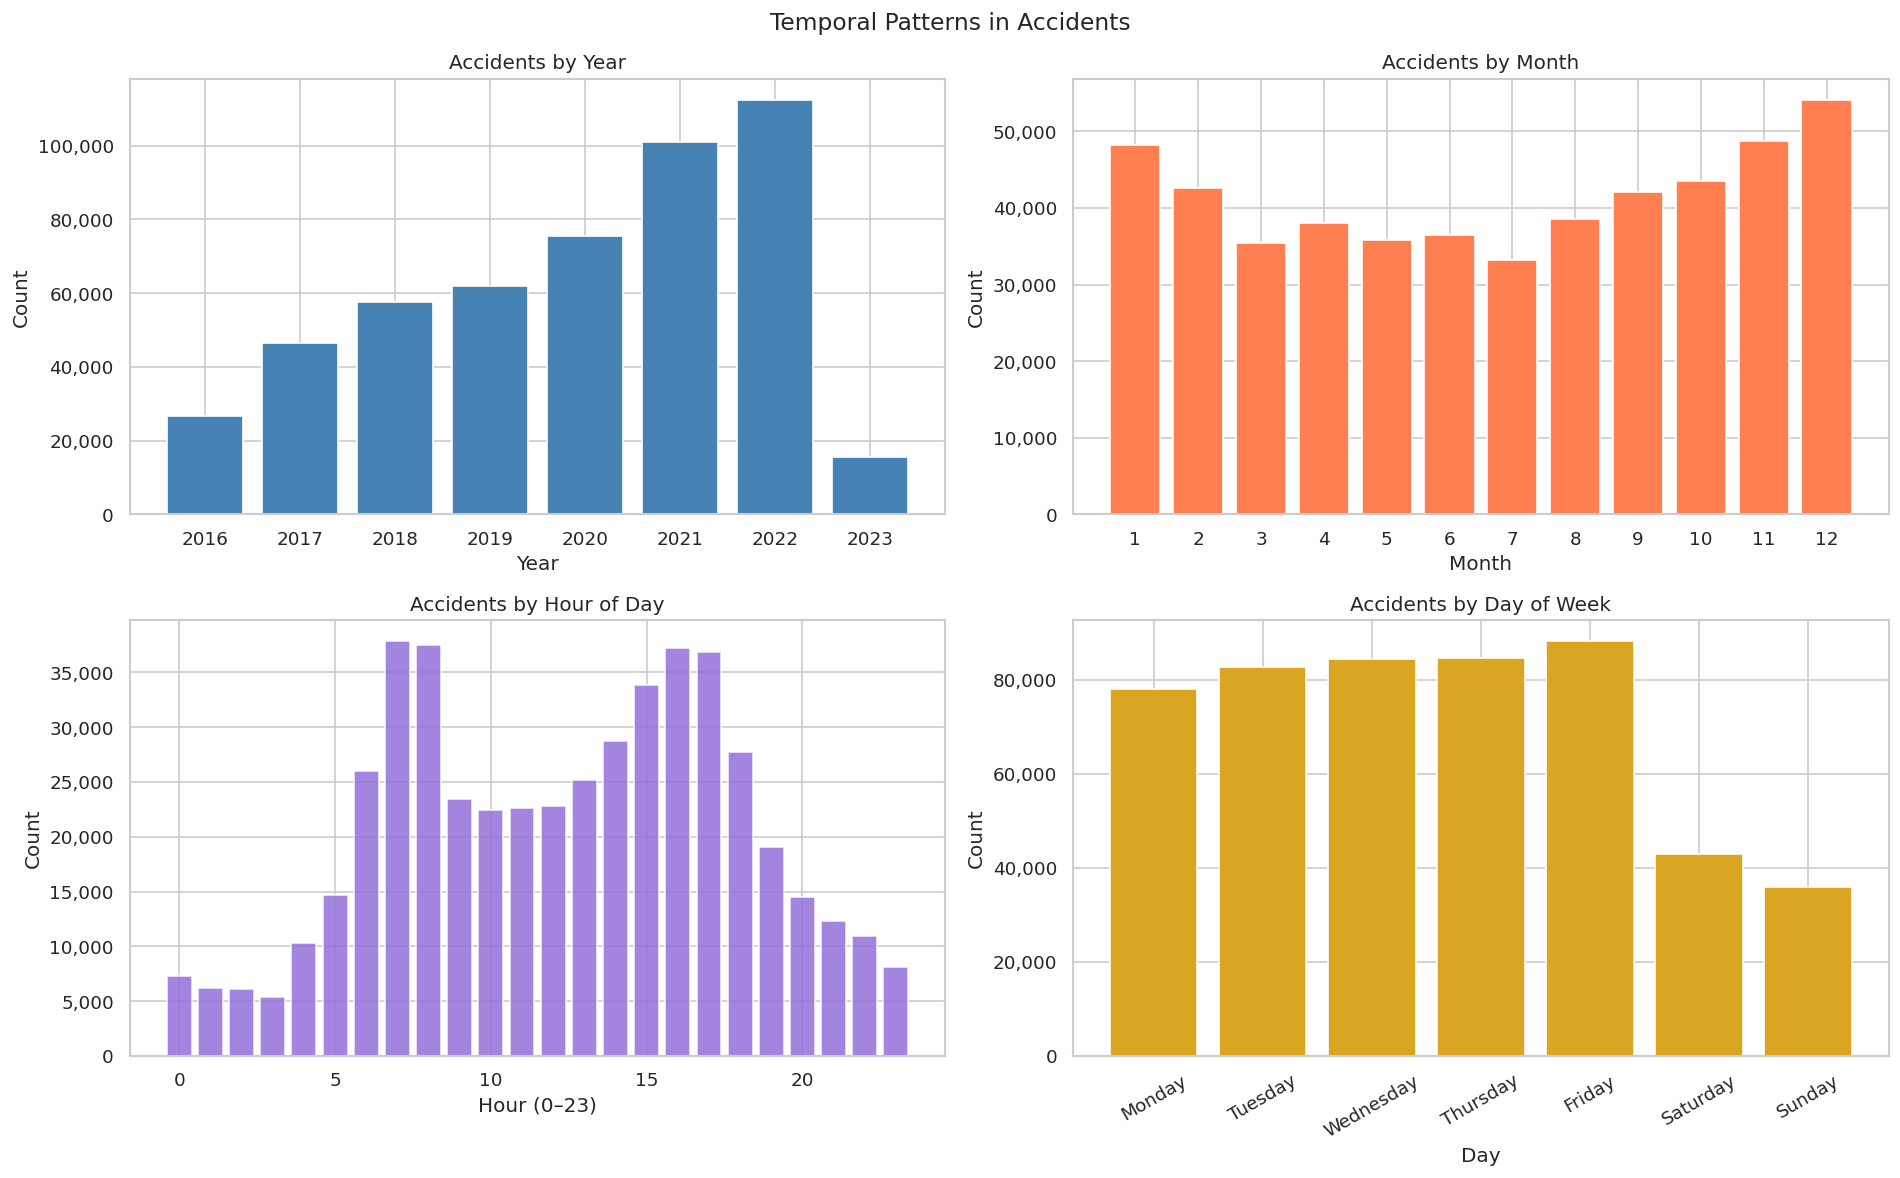

In [53]:
# 11. DATETIME ANALYSIS
print("\n" + "=" * 70)
print("11. DATETIME ANALYSIS — Start_Time")
print("=" * 70)

df["Start_Time_dt"] = pd.to_datetime(df["Start_Time"], errors="coerce")
n_invalid_dt = df["Start_Time_dt"].isnull().sum()
print(f"Unparseable timestamps : {n_invalid_dt:,}")
print(f"Date range             : {df['Start_Time_dt'].min()} → {df['Start_Time_dt'].max()}")

df["year"]  = df["Start_Time_dt"].dt.year
df["month"] = df["Start_Time_dt"].dt.month
df["hour"]  = df["Start_Time_dt"].dt.hour
df["dow"]   = df["Start_Time_dt"].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

year_counts = df["year"].value_counts().sort_index()
axes[0, 0].bar(year_counts.index.astype(str), year_counts.values, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Accidents by Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Count")
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

month_counts = df["month"].value_counts().sort_index()
axes[0, 1].bar(month_counts.index, month_counts.values, color="coral", edgecolor="white")
axes[0, 1].set_title("Accidents by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

hour_counts = df["hour"].value_counts().sort_index()
axes[1, 0].bar(hour_counts.index, hour_counts.values, color="mediumpurple", edgecolor="white", alpha=0.85)
axes[1, 0].set_title("Accidents by Hour of Day")
axes[1, 0].set_xlabel("Hour (0–23)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = df["dow"].value_counts().reindex(dow_order)
axes[1, 1].bar(dow_counts.index, dow_counts.values, color="goldenrod", edgecolor="white")
axes[1, 1].set_title("Accidents by Day of Week")
axes[1, 1].set_xlabel("Day")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Temporal Patterns in Accidents", fontsize=14)
plt.show()


12. GEOGRAPHIC OVERVIEW
Latitude  range : 24.5621 → 48.9996
Longitude range : -124.4974 → -67.4841


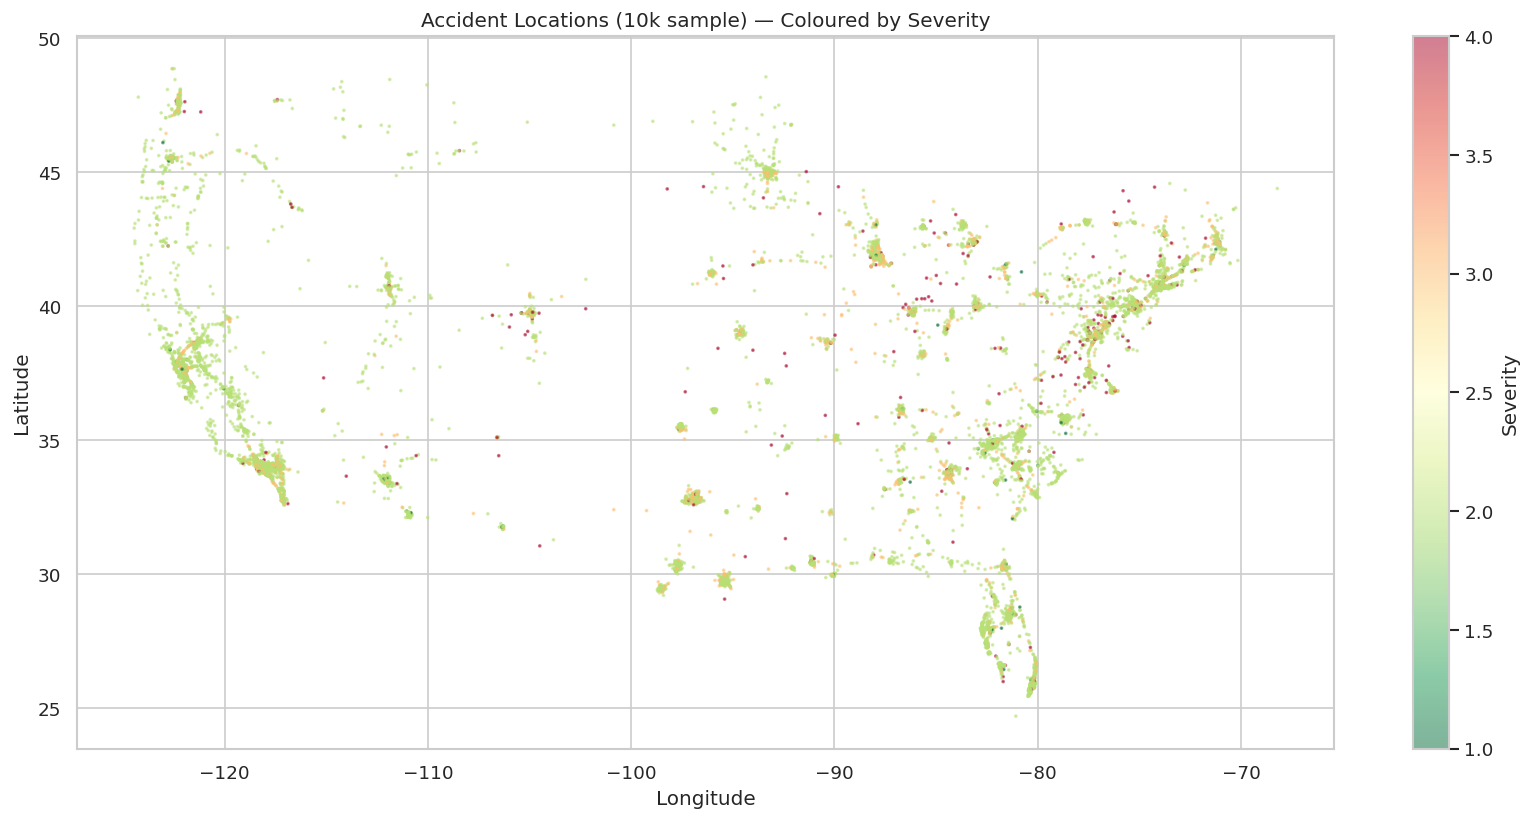

In [54]:
# 12. GEOGRAPHIC OVERVIEW
print("\n" + "=" * 70)
print("12. GEOGRAPHIC OVERVIEW")
print("=" * 70)

print(f"Latitude  range : {df['Start_Lat'].min():.4f} → {df['Start_Lat'].max():.4f}")
print(f"Longitude range : {df['Start_Lng'].min():.4f} → {df['Start_Lng'].max():.4f}")

sample = df[["Start_Lat", "Start_Lng", "Severity"]].dropna().sample(
    min(10_000, len(df)), random_state=42
)
fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    sample["Start_Lng"], sample["Start_Lat"],
    c=sample["Severity"], cmap="RdYlGn_r",
    s=1.5, alpha=0.5,
)
plt.colorbar(scatter, ax=ax, label="Severity")
ax.set_title("Accident Locations (10k sample) — Coloured by Severity")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


13. SEVERITY vs FEATURES

-- Mean of numeric features per Severity class --
          Start_Lat  Start_Lng  Temperature(F)  Visibility(mi)  Humidity(%)
Severity                                                                   
1            35.664    -94.655       72.319000           9.520    62.480999
2            36.067    -95.130       61.512001           9.082    64.700996
3            36.675    -93.944       62.217999           9.112    65.313004
4            37.864    -88.625       58.214001           9.097    67.009003


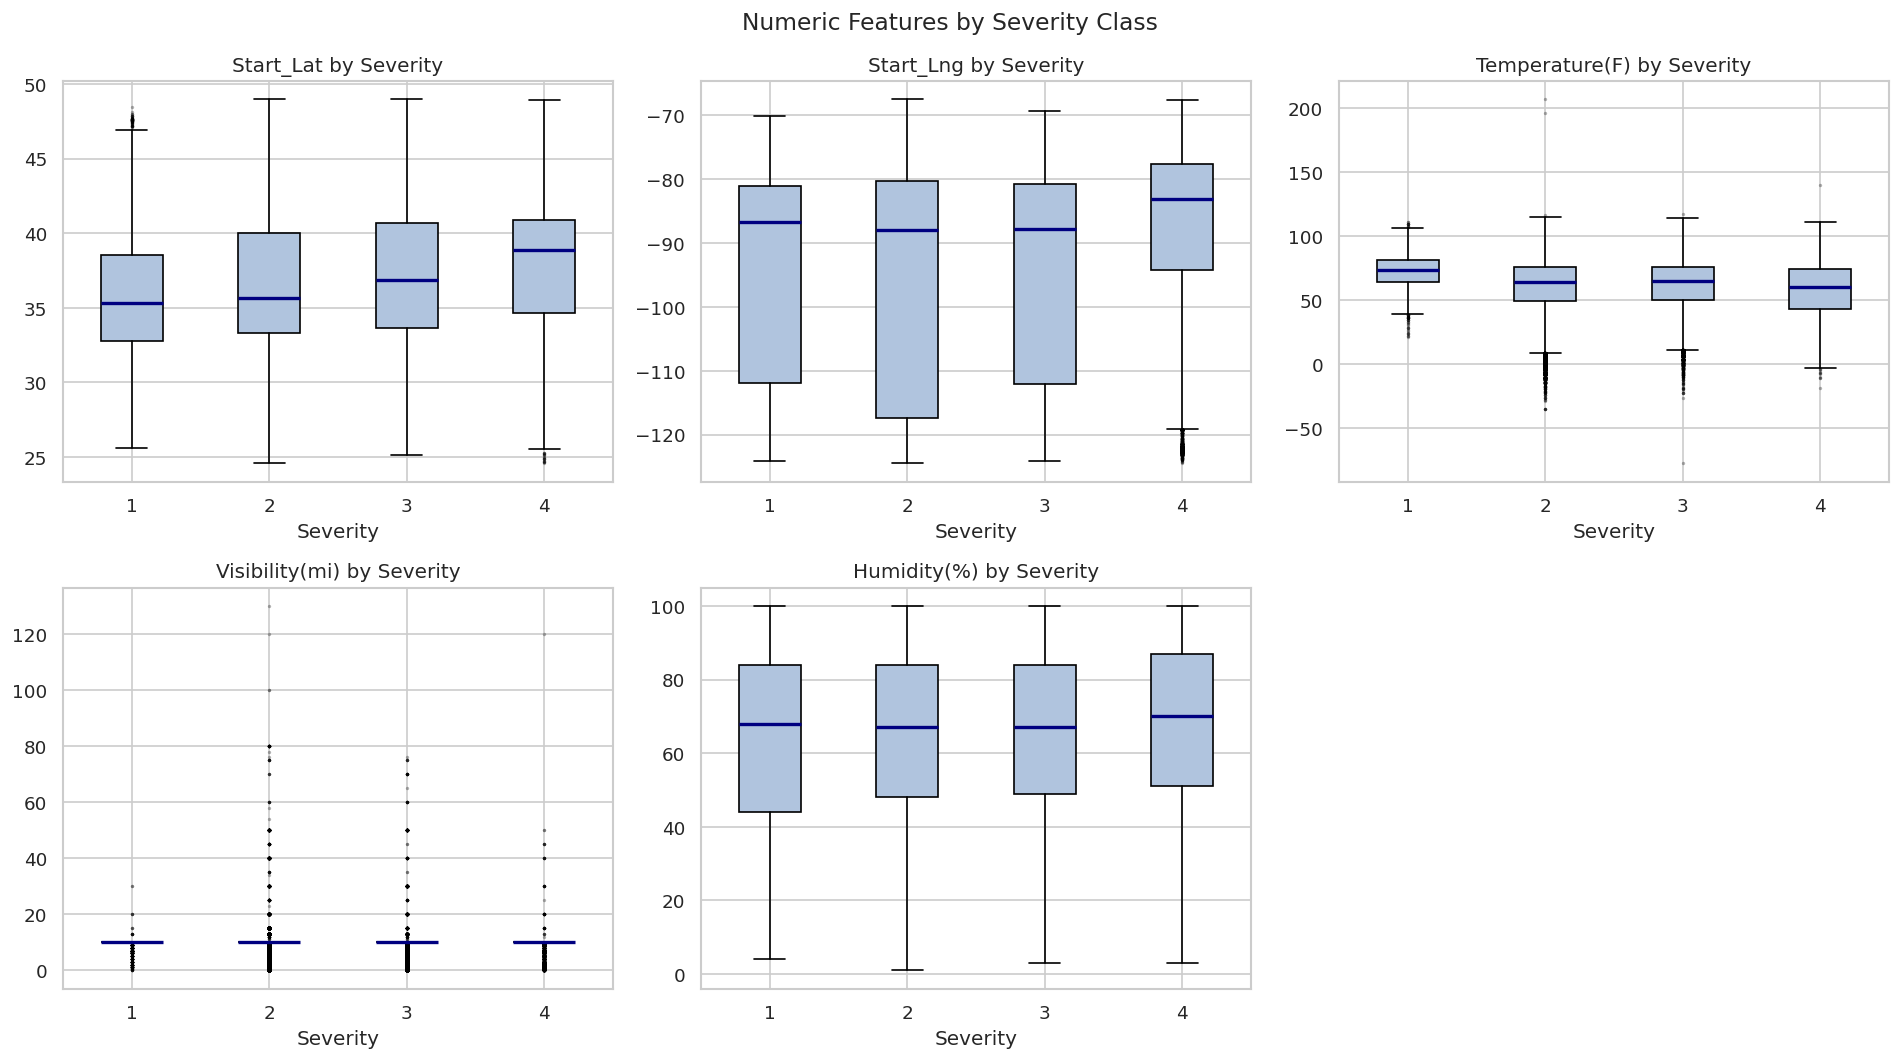


-- Boolean flag True-rates per Severity class (%) --
          Junction  Traffic_Signal  Crossing  Stop
Severity                                          
1             4.89           39.10     27.44  3.88
2             6.74           16.45     12.82  3.26
3            10.29            6.87      3.76  0.61
4            10.14            9.67      6.25  2.73


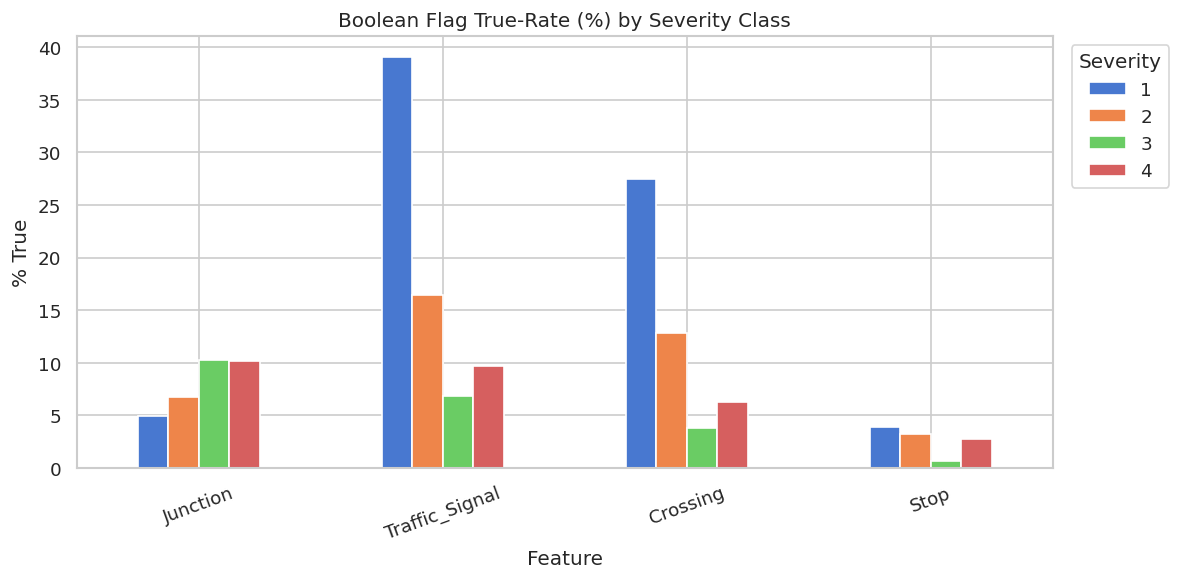


-- Severity counts by Sunrise_Sunset --
Severity           1       2      3     4
Sunrise_Sunset                           
Day             3455  271315  60619  7564
Night            785  122793  23815  5300


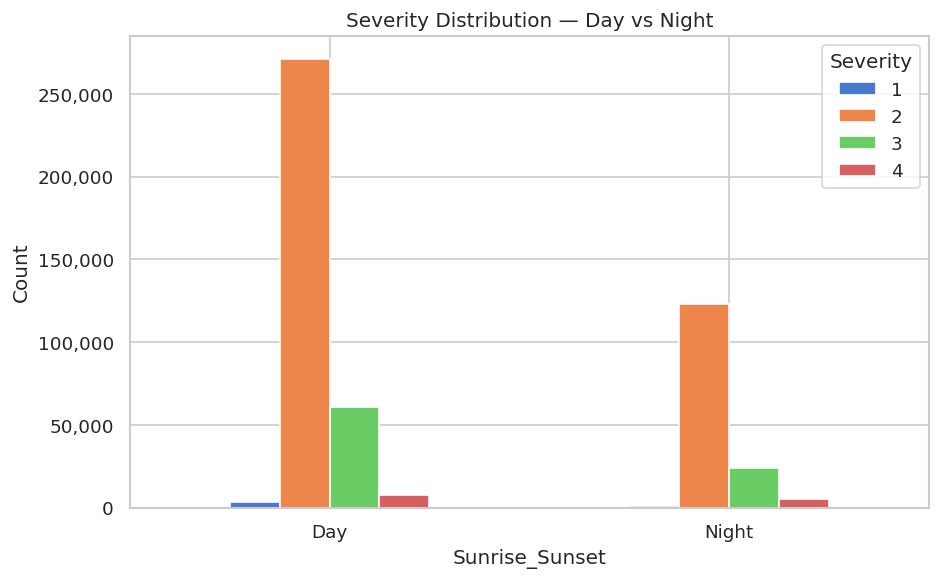

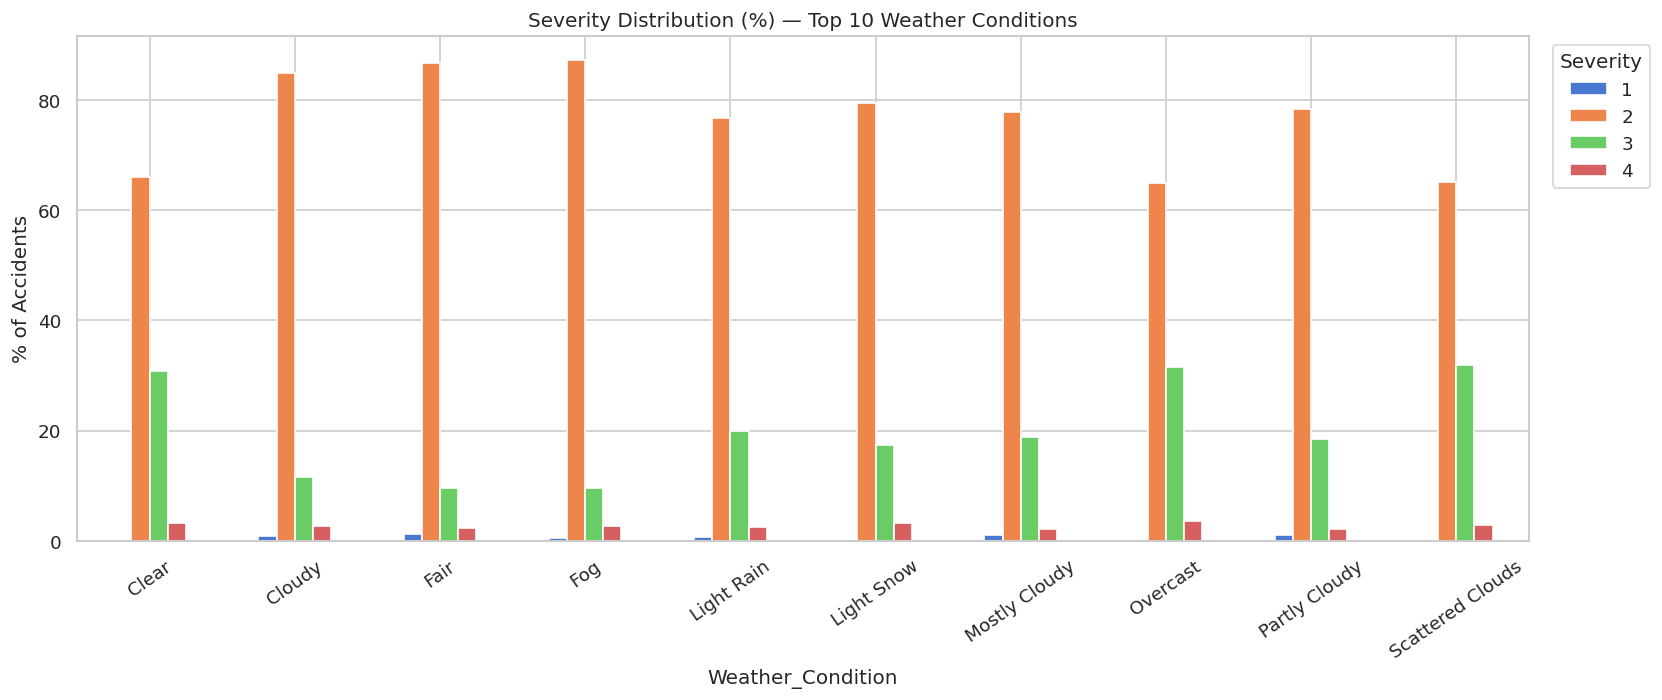

In [55]:
# 13. SEVERITY vs FEATURES
print("\n" + "=" * 70)
print("13. SEVERITY vs FEATURES")
print("=" * 70)

print("\n-- Mean of numeric features per Severity class --")
print(df.groupby("Severity")[NUMERIC_COLS].mean().round(3).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
severity_levels = sorted(df["Severity"].dropna().unique())

for i, col in enumerate(NUMERIC_COLS):
    groups = [df.loc[df["Severity"] == s, col].dropna().values for s in severity_levels]
    axes[i].boxplot(
        groups, labels=severity_levels, patch_artist=True,
        boxprops=dict(facecolor="lightsteelblue"),
        medianprops=dict(color="navy", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    axes[i].set_title(f"{col} by Severity")
    axes[i].set_xlabel("Severity")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Features by Severity Class", fontsize=14)
plt.show()

print("\n-- Boolean flag True-rates per Severity class (%) --")
bool_by_sev = df.groupby("Severity")[BOOLEAN_COLS].mean().mul(100).round(2)
print(bool_by_sev.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bool_by_sev.T.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Boolean Flag True-Rate (%) by Severity Class")
ax.set_ylabel("% True")
ax.set_xlabel("Feature")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Severity", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

print("\n-- Severity counts by Sunrise_Sunset --")
sev_daynight = df.groupby(["Sunrise_Sunset", "Severity"]).size().unstack(fill_value=0)
print(sev_daynight.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
sev_daynight.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Severity Distribution — Day vs Night")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Severity")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

top10_weather = df["Weather_Condition"].value_counts().head(10).index
df_w = df[df["Weather_Condition"].isin(top10_weather)]
sev_weather = df_w.groupby(["Weather_Condition", "Severity"]).size().unstack(fill_value=0)
sev_weather_pct = sev_weather.div(sev_weather.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sev_weather_pct.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Severity Distribution (%) — Top 10 Weather Conditions")
ax.set_ylabel("% of Accidents")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Severity", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

In [56]:
# 14. CLASS IMBALANCE CHECK
print("\n" + "=" * 70)
print("14. CLASS IMBALANCE CHECK")
print("=" * 70)

sev_dist = df["Severity"].value_counts().sort_index()
imbalance_ratio = sev_dist.max() / sev_dist.min()
print(f"Imbalance ratio (max/min class): {imbalance_ratio:.1f}x")
print(f"Majority class : Severity {sev_dist.idxmax()} ({sev_dist.max():,} samples, "
      f"{sev_dist.max()/len(df)*100:.1f}%)")
print(f"Minority class : Severity {sev_dist.idxmin()} ({sev_dist.min():,} samples, "
      f"{sev_dist.min()/len(df)*100:.1f}%)")
print("\n→ Consider: class_weight='balanced', SMOTE, or stratified sampling during preprocessing.")


14. CLASS IMBALANCE CHECK
Imbalance ratio (max/min class): 93.0x
Majority class : Severity 2 (395,367 samples, 79.5%)
Minority class : Severity 1 (4,253 samples, 0.9%)

→ Consider: class_weight='balanced', SMOTE, or stratified sampling during preprocessing.


In [57]:
# 15. FINAL SUMMARY
print("\n" + "=" * 70)
print("15. FINAL EDA SUMMARY")
print("=" * 70)

miss_max_col = missing_nonzero["missing_%"].idxmax() if not missing_nonzero.empty else "None"
miss_max_pct = missing_nonzero["missing_%"].max()    if not missing_nonzero.empty else 0.0

print(f"""
Dataset shape            : {df.shape[0]:,} rows × {len(COLUMNS_TO_KEEP)} selected columns
Memory usage             : {mem_mb:.1f} MB
Duplicate rows           : {n_dup:,}

── Missing values ──────────────────────────────────────
  Columns with NaNs      : {len(missing_nonzero)}
  Highest missing        : {miss_max_col} ({miss_max_pct:.1f}%)

── Target (Severity) ───────────────────────────────────
  Unique classes         : {df['Severity'].nunique()}
  Class distribution     : { {k: f'{v/len(df)*100:.1f}%' for k, v in sev_counts.items()} }
  Imbalance ratio        : {imbalance_ratio:.1f}x  ← address before modelling

── Temporal ────────────────────────────────────────────
  Date range             : {df['Start_Time_dt'].min().date()} → {df['Start_Time_dt'].max().date()}
  Invalid timestamps     : {n_invalid_dt:,}

── Geographic ──────────────────────────────────────────
  States                 : {df['State'].nunique()}
  Cities                 : {df['City'].nunique():,}

── Categorical ─────────────────────────────────────────
  Weather conditions     : {df['Weather_Condition'].nunique()} unique (consider grouping rare ones)
  Day / Night split      : {df['Sunrise_Sunset'].value_counts().to_dict()}

── Boolean flags (% True) ──────────────────────────────
{bool_summary['True_%'].to_string()}
""")

print("EDA complete.")


15. FINAL EDA SUMMARY

Dataset shape            : 497,116 rows × 15 selected columns
Memory usage             : 123.9 MB
Duplicate rows           : 0

── Missing values ──────────────────────────────────────
  Columns with NaNs      : 5
  Highest missing        : Visibility(mi) (2.3%)

── Target (Severity) ───────────────────────────────────
  Unique classes         : 4
  Class distribution     : {1: '0.9%', 2: '79.5%', 3: '17.0%', 4: '2.6%'}
  Imbalance ratio        : 93.0x  ← address before modelling

── Temporal ────────────────────────────────────────────
  Date range             : 2016-01-14 → 2023-03-31
  Invalid timestamps     : 0

── Geographic ──────────────────────────────────────────
  States                 : 49
  Cities                 : 9,489

── Categorical ─────────────────────────────────────────
  Weather conditions     : 108 unique (consider grouping rare ones)
  Day / Night split      : {'Day': 342953, 'Night': 152693}

── Boolean flags (% True) ───────────────────

### **EDA (AFTER)**

In [ ]:
# EDA SETUP
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, round as spark_round, desc, year as spark_year
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

spark = SparkSession.builder.appName("4Wheels_EDA").getOrCreate()
df = spark.read.parquet("/content/drive/MyDrive/Big Data/Final.parquet")

print("Loaded successfully!")
print("Total rows   :", df.count())
print("Total columns:", len(df.columns))
print("Columns      :", df.columns)

null_time = df.filter(col("Start_Time").isNull()).count()
print(f"\nNull timestamps (should be 0): {null_time}")

Loaded successfully!
Total rows   : 497116
Total columns: 18
Columns      : ['Severity', 'Start_Time', 'City', 'State', 'Start_Lat', 'Start_Lng', 'Weather_Condition', 'Temperature(F)', 'Visibility(mi)', 'Humidity(%)', 'Sunrise_Sunset', 'Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Hour', 'Day_of_Week', 'Month']

Null timestamps (should be 0): 0


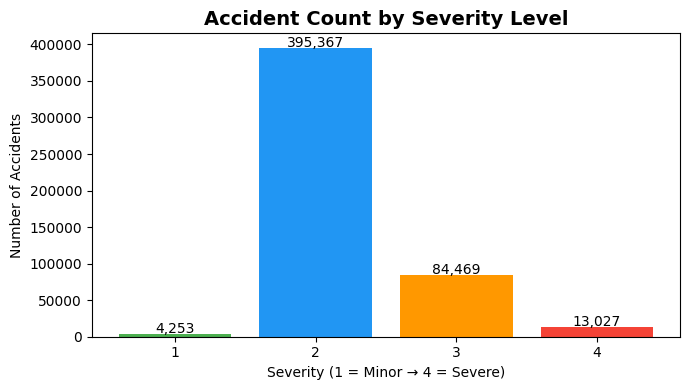

In [ ]:
# EDA 1: SEVERITY DISTRIBUTION
# Are most accidents minor or severe?
severity_df = df.groupBy("Severity").count().orderBy("Severity").toPandas()

plt.figure(figsize=(7, 4))
bars = plt.bar(severity_df["Severity"], severity_df["count"],
               color=["#4CAF50", "#2196F3", "#FF9800", "#F44336"])
plt.title("Accident Count by Severity Level", fontsize=14, fontweight="bold")
plt.xlabel("Severity (1 = Minor → 4 = Severe)")
plt.ylabel("Number of Accidents")
plt.xticks([1, 2, 3, 4])
for bar, val in zip(bars, severity_df["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

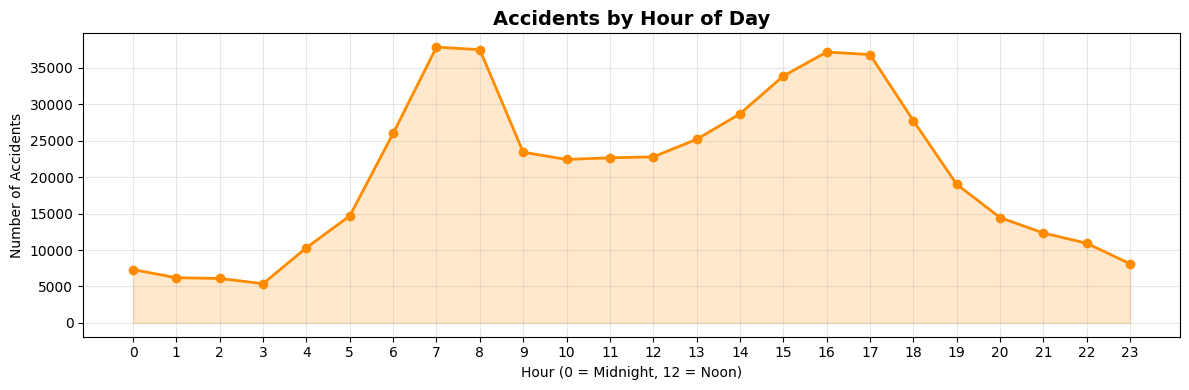

In [ ]:
# EDA 2: ACCIDENTS BY HOUR OF DAY
hour_df = df.groupBy("Hour").count().orderBy("Hour").toPandas()

plt.figure(figsize=(12, 4))
plt.plot(hour_df["Hour"], hour_df["count"], marker="o", color="darkorange", linewidth=2)
plt.fill_between(hour_df["Hour"], hour_df["count"], alpha=0.2, color="darkorange")
plt.title("Accidents by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour (0 = Midnight, 12 = Noon)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

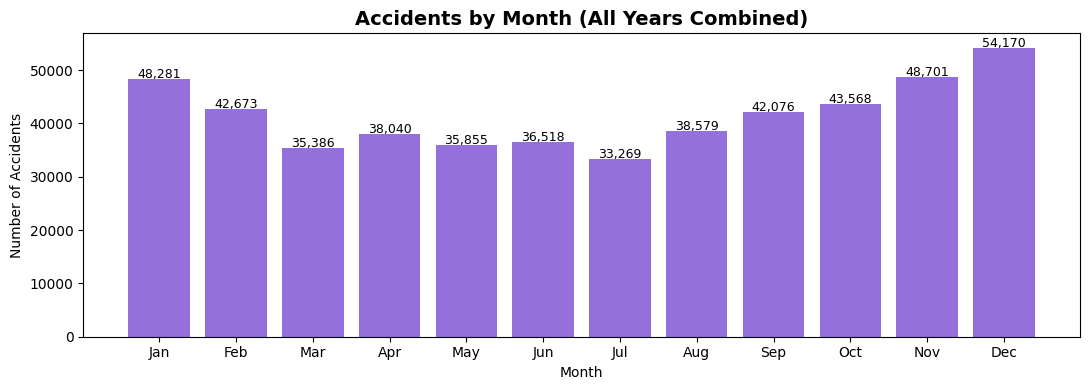

In [ ]:
# EDA 3: ACCIDENTS BY MONTH (collapsed across all years, seasonal pattern)
month_labels = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
month_df = df.groupBy("Month").count().orderBy("Month").toPandas()
month_df["Month_Label"] = month_df["Month"].map(month_labels)

plt.figure(figsize=(11, 4))
bars = plt.bar(month_df["Month_Label"], month_df["count"], color="mediumpurple")
plt.title("Accidents by Month (All Years Combined)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
for bar, val in zip(bars, month_df["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

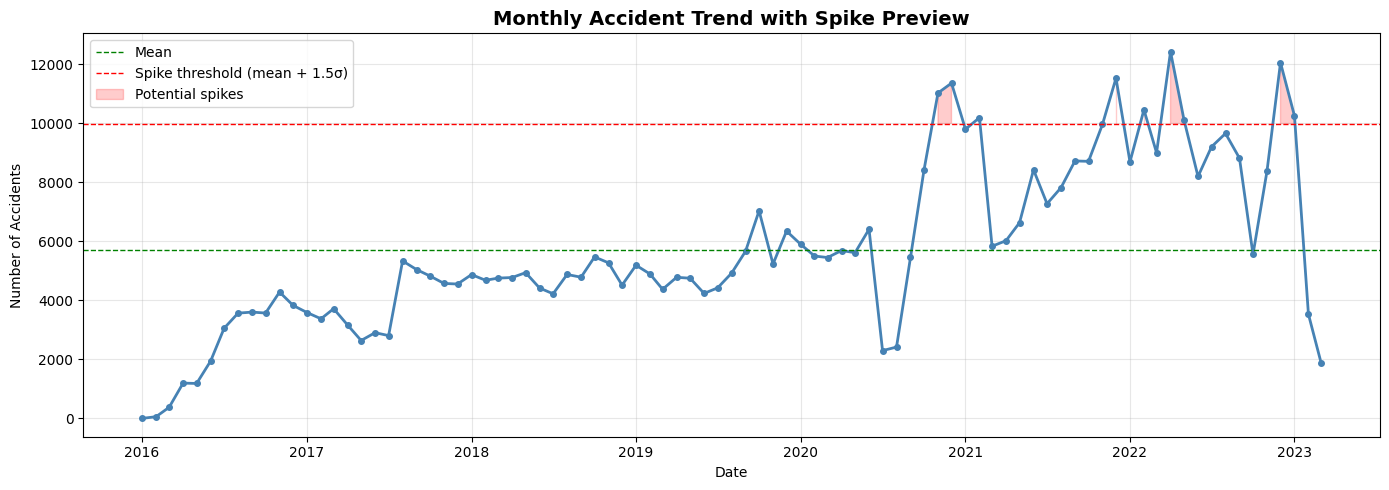

In [ ]:
# EDA 4: MONTHLY TREND WITH SPIKE PREVIEW (Objective 2)
# Visualizes the overall accident trend and highlights months that exceed the spike threshold, motivating the use of Isolation Forest.
from pyspark.sql.functions import year as spark_year

monthly_trend = (
    df.groupBy(spark_year("Start_Time").alias("Year"), "Month")
      .count()
      .orderBy("Year", "Month")
      .toPandas()
)
monthly_trend["date"] = pd.to_datetime(
    monthly_trend[["Year", "Month"]].assign(day=1)
)
monthly_trend = monthly_trend.sort_values("date").reset_index(drop=True)

mean_count = monthly_trend["count"].mean()
std_count  = monthly_trend["count"].std()
threshold  = mean_count + 1.5 * std_count

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend["date"], monthly_trend["count"],
         color="steelblue", linewidth=2, marker="o", markersize=4)
plt.axhline(y=mean_count, color="green",  linestyle="--", linewidth=1, label="Mean")
plt.axhline(y=threshold,  color="red",    linestyle="--", linewidth=1, label="Spike threshold (mean + 1.5σ)")
plt.fill_between(monthly_trend["date"], threshold, monthly_trend["count"],
                 where=monthly_trend["count"] > threshold,
                 color="red", alpha=0.2, label="Potential spikes")
plt.title("Monthly Accident Trend with Spike Preview", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Number of Accidents")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

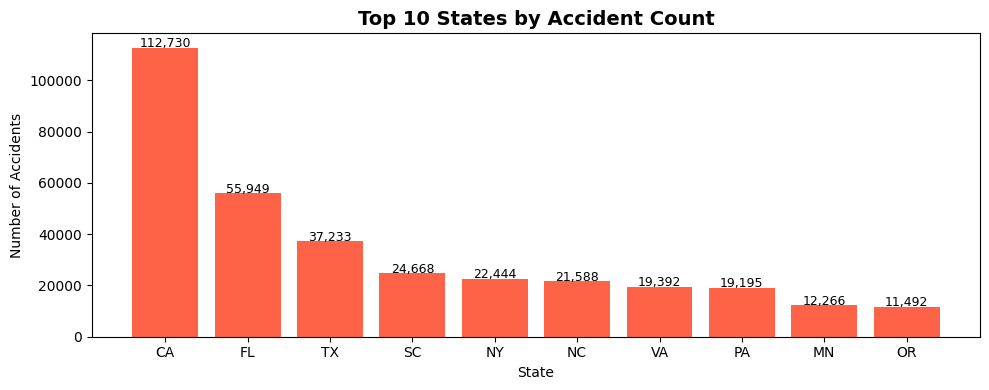

In [ ]:
# EDA 5: TOP 10 STATES BY ACCIDENT COUNT
state_df = df.groupBy("State").count().orderBy(desc("count")).limit(10).toPandas()

plt.figure(figsize=(10, 4))
bars = plt.bar(state_df["State"], state_df["count"], color="tomato")
plt.title("Top 10 States by Accident Count", fontsize=14, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
for bar, val in zip(bars, state_df["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

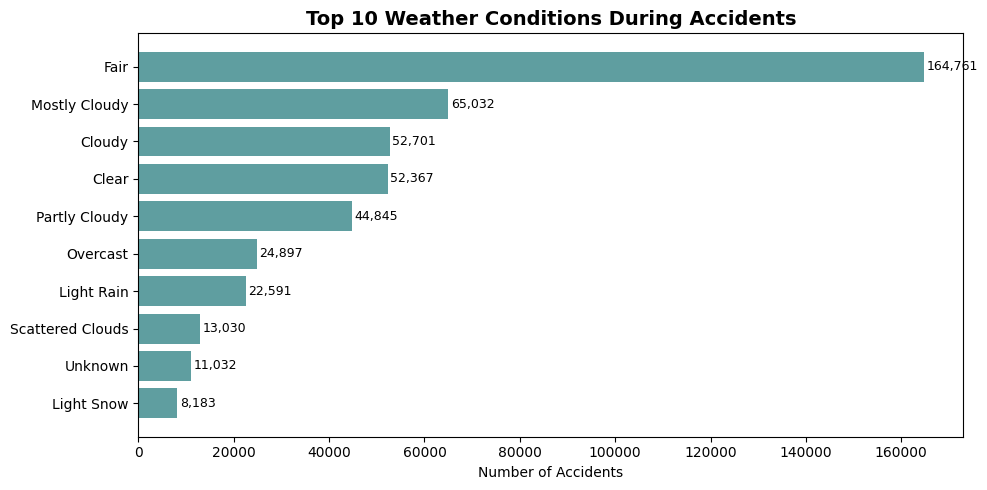

In [ ]:
# EDA 6: WEATHER CONDITION vs ACCIDENT COUNT
weather_df = (
    df.groupBy("Weather_Condition")
      .count()
      .orderBy(desc("count"))
      .limit(10)
      .toPandas()
)

plt.figure(figsize=(10, 5))
plt.barh(weather_df["Weather_Condition"], weather_df["count"], color="cadetblue")
plt.title("Top 10 Weather Conditions During Accidents", fontsize=14, fontweight="bold")
plt.xlabel("Number of Accidents")
plt.gca().invert_yaxis()
for i, val in enumerate(weather_df["count"]):
    plt.text(val + 500, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

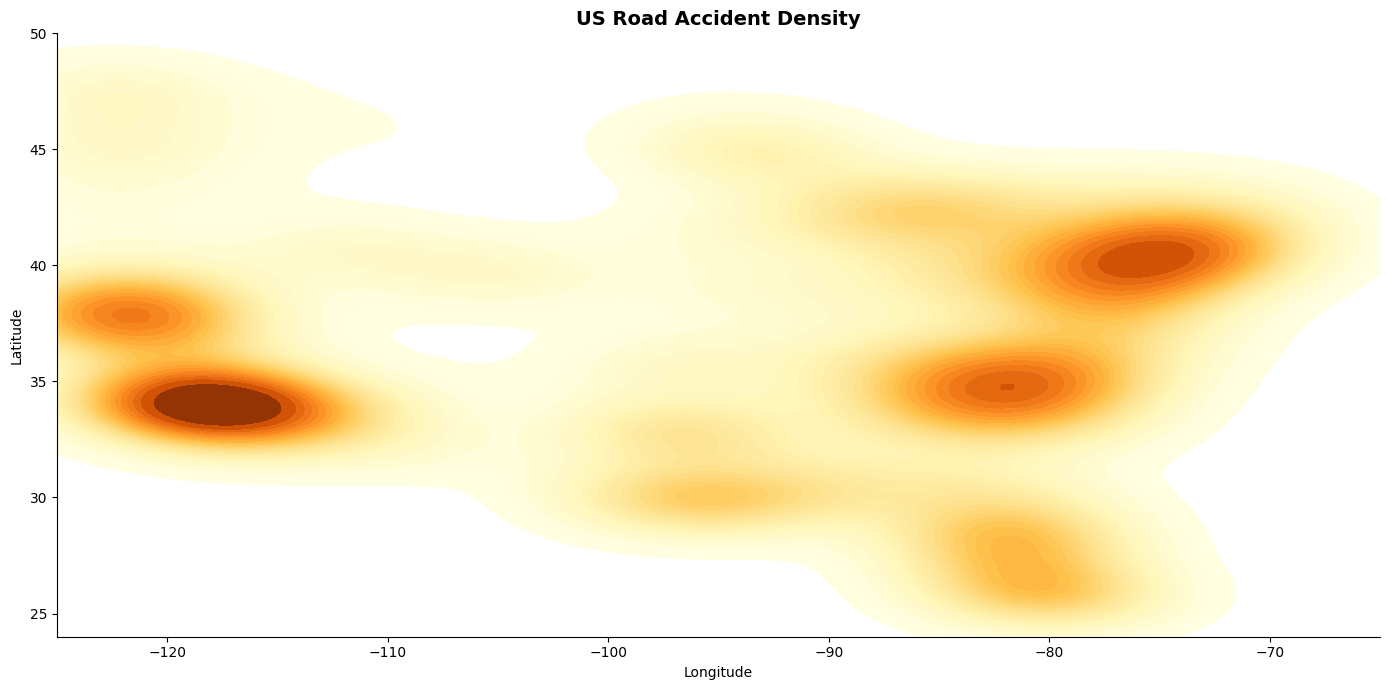

In [ ]:
# EDA 7 — GEOGRAPHIC ACCIDENT DENSITY HEATMAP (Objective 1)
# Sampling 2% to keep rendering fast while preserving spatial distribution.
geo_df = (
    df.select("Start_Lat", "Start_Lng")
      .dropna()
      .sample(fraction=0.02, seed=42)
      .toPandas()
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.kdeplot(
    data=geo_df, x="Start_Lng", y="Start_Lat",
    fill=True, cmap="YlOrBr", levels=30, thresh=0.02, ax=ax
)
ax.set_xlim(-125, -65)
ax.set_ylim(24, 50)
ax.set_title("US Road Accident Density", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## **BASELINE MODELING**

Objective 1: To analyze patterns and trends in road accident frequency across urban areas and time periods to identify locations that pose the greatest risk to public health and safety.


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import count
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline

spark = SparkSession.builder.appName("4Wheels").getOrCreate()
df = spark.read.parquet("/content/drive/MyDrive/Big Data/Final.parquet")

print("Total rows:", df.count())
print("Columns:", df.columns)

df_agg = df.groupBy(
    "City", "State","Month").agg(count("*").alias("accident_count"))

print("Aggregated rows:", df_agg.count())
df_agg.show(5)

df_agg.describe("accident_count").show()

indexers = [
    StringIndexer(inputCol="City", outputCol="City_Index", handleInvalid="keep"),
    StringIndexer(inputCol="State", outputCol="State_Index", handleInvalid="keep"),
]

feature_cols = [
    "City_Index", "State_Index", "Month"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

rf = RandomForestRegressor(
    labelCol="accident_count",
    featuresCol="features",
    seed=42,
    maxBins=10000
)

pipeline = Pipeline(stages=indexers + [assembler, rf])

train_df, test_df = df_agg.randomSplit([0.8, 0.2], seed=42)
print("Train size:", train_df.count())
print("Test size: ", test_df.count())

Total rows: 497116
Columns: ['Severity', 'Start_Time', 'City', 'State', 'Start_Lat', 'Start_Lng', 'Weather_Condition', 'Temperature(F)', 'Visibility(mi)', 'Humidity(%)', 'Sunrise_Sunset', 'Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Hour', 'Day_of_Week', 'Month']
Aggregated rows: 67095
+---------+-----+-----+--------------+
|     City|State|Month|accident_count|
+---------+-----+-----+--------------+
|Nashville|   TN|   11|           438|
| Brooklyn|   NY|   11|           108|
| Meridian|   ID|   12|            26|
|  Melrose|   FL|    9|             3|
|     Irmo|   SC|    6|            17|
+---------+-----+-----+--------------+
only showing top 5 rows
+-------+-----------------+
|summary|   accident_count|
+-------+-----------------+
|  count|            67095|
|   mean|7.409136299277145|
| stddev|34.47752242922766|
|    min|                1|
|    max|             1444|
+-------+-----------------+

Train size: 53787
Test size:  13308


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### **TRAINING FOR OBJECTIVE 1**

In [ ]:
model = pipeline.fit(train_df)
print("Model training complete.")

predictions = model.transform(test_df)
print("Predictions generated.")

predictions.select("City", "State", "Month", "accident_count", "prediction").show(10)

from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(labelCol="accident_count", predictionCol="prediction", metricName="rmse")
print("RMSE:", evaluator.evaluate(predictions))

evaluator.setMetricName("r2")
print("R2:", evaluator.evaluate(predictions))

Model training complete.
Predictions generated.
+-----------+-----+-----+--------------+------------------+
|       City|State|Month|accident_count|        prediction|
+-----------+-----+-----+--------------+------------------+
|  Abbeville|   SC|    1|             1|1.0522385092704996|
|  Abbeville|   SC|    3|             1|1.0221307918877334|
|  Abbeville|   SC|    4|             1|1.0283084291169746|
|  Abbeville|   SC|    9|             1| 1.022404426926555|
|     Abbott|   TX|    1|             1|1.5866932567179874|
|Abbottstown|   PA|    4|             1| 1.082717647413377|
|   Aberdeen|   MD|    1|             1|  1.02615015200318|
|   Aberdeen|   MD|    6|             1|1.0130125004718624|
|   Aberdeen|   MD|    8|             1|1.0224207447636227|
|   Aberdeen|   MD|    8|             1|1.0284407354242764|
+-----------+-----+-----+--------------+------------------+
only showing top 10 rows
RMSE: 0.31039290837352157
R2: 0.08503149422628542


Objective 2:
To identify unusual spikes in accident occurrences during specific time periods that fall outside normal accident trends.

In [ ]:
# BASELINE MODELING: ISOLATION FOREST
# Objective 2: Detect months with unusual spikes in accident frequency.
from pyspark.sql.functions import year as spark_year
from sklearn.ensemble import IsolationForest
import pandas as pd

monthly = (
    df.groupBy(spark_year("Start_Time").alias("Year"), "Month")
      .count()
      .orderBy("Year", "Month")
      .toPandas()
)

monthly["Date"] = pd.to_datetime(monthly[["Year", "Month"]].assign(Day=1))
monthly = monthly.sort_values("Date").reset_index(drop=True)
monthly["Month_Year"] = monthly["Date"].dt.strftime("%b %Y")

print(f"Total monthly records: {len(monthly)}")
print(f"Date range: {monthly['Month_Year'].iloc[0]} → {monthly['Month_Year'].iloc[-1]}")
print(f"\nMonthly accident count summary:")
print(f"  Min  : {monthly['count'].min():,}  ({monthly.loc[monthly['count'].idxmin(), 'Month_Year']})")
print(f"  Max  : {monthly['count'].max():,}  ({monthly.loc[monthly['count'].idxmax(), 'Month_Year']})")
print(f"  Mean : {monthly['count'].mean():,.0f}")
print(f"  Std  : {monthly['count'].std():,.0f}")
print(f"\nFirst 3 months: ")
print(monthly[["Month_Year", "count"]].head(3).to_string(index=False))
print(f"\nLast 3 months:")
print(monthly[["Month_Year", "count"]].tail(3).to_string(index=False))

Total monthly records: 87
Date range: Jan 2016 → Mar 2023

Monthly accident count summary:
  Min  : 1  (Jan 2016)
  Max  : 12,422  (Apr 2022)
  Mean : 5,714
  Std  : 2,847

First 3 months: 
Month_Year  count
  Jan 2016      1
  Feb 2016     58
  Mar 2016    377

Last 3 months:
Month_Year  count
  Jan 2023  10250
  Feb 2023   3529
  Mar 2023   1889


In [ ]:
# Prepare features for the baseline model.
features = monthly[["count"]].values

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

print("Baseline Isolation Forest initialized.")
print(f"  n_estimators  : {iso_forest.n_estimators}")
print(f"  contamination : {iso_forest.contamination}")
print(f"  random_state  : {iso_forest.random_state}")
print("\nModel is ready for training.")

Baseline Isolation Forest initialized.
  n_estimators  : 100
  contamination : 0.05
  random_state  : 42

Model is ready for training.


#### **TRAINING FOR OBJECTIVE 2**

In [ ]:
iso_forest.fit(features)
print("Model training complete.")

monthly["anomaly"] = iso_forest.predict(features)

monthly["anomaly_label"] = monthly["anomaly"].map({
    1: "Normal",
    -1: "Spike"
})

monthly["anomaly_score"] = iso_forest.decision_function(features)

spikes = monthly[monthly["anomaly"] == -1]
normal = monthly[monthly["anomaly"] == 1]

print("Total months analyzed:", len(monthly))
print("Normal months:", len(normal))
print("Spike months detected:", len(spikes))

print("\nDetected Spike Months:")
print(spikes[["Month_Year", "count", "anomaly_score"]].to_string(index=False))

Model training complete.
Total months analyzed: 87
Normal months: 82
Spike months detected: 5

Detected Spike Months:
Month_Year  count  anomaly_score
  Jan 2016      1      -0.029661
  Feb 2016     58      -0.013199
  Mar 2016    377      -0.035244
  Apr 2022  12422      -0.060171
  Dec 2022  12050      -0.013033
